In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [4]:
x=df[['underground_wave_energy','vibration_axis_variation']].values
y=df['seismic_event_detected'].values

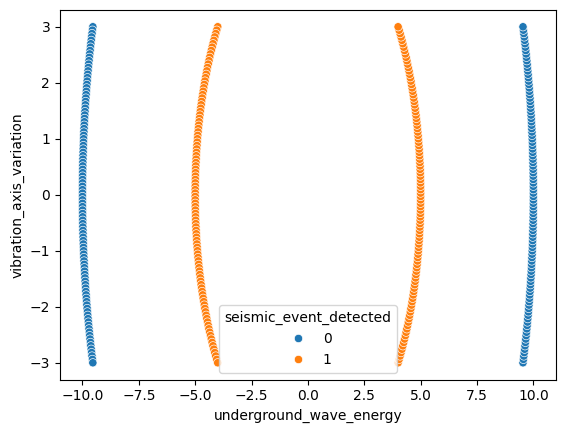

In [5]:
sns.scatterplot(x=df['underground_wave_energy'],y=df['vibration_axis_variation'],hue=df['seismic_event_detected'])
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
x_test=torch.tensor(x_test,dtype=torch.float32)
x_train=torch.tensor(x_train,dtype=torch.float32)

y_test=torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)
y_train=torch.tensor(y_train,dtype=torch.float32).unsqueeze(1)

In [9]:
print(x_train.shape,y_train.shape)

print(x_test.shape,y_test.shape)


torch.Size([320, 2]) torch.Size([320, 1])
torch.Size([80, 2]) torch.Size([80, 1])


In [10]:
import torch.nn as nn

In [ ]:
class odevmodulu(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1=nn.Linear(in_features=2,out_features=10)
        self.layer2=nn.Linear(in_features=10,out_features=1)
        self.relu = nn.ReLU()
    def forward(self,x):
        return self.layer2(self.relu(self.layer1(x)))

In [12]:
model_0=odevmodulu()

In [13]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(params=model_0.parameters(),lr=0.01)

In [14]:
def dogruluk_hesapla(y_test,y_pred):
    dogru_sayisi= torch.eq(y_test,y_pred).sum().item()
    basari_yuzdesi = (dogru_sayisi/len(y_pred)*100)
    return basari_yuzdesi

In [15]:
torch.manual_seed(42)
epoch=150

for epoch in range(epoch):
    model_0.train()

    y_logit=model_0(x_train)
    y_pred=torch.round(torch.sigmoid(y_logit))

    loss=loss_fn(y_logit,y_train)
    acc = dogruluk_hesapla(y_test=y_train,y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logit=model_0(x_test)
        test_pred=torch.round(torch.sigmoid(test_logit))

        test_loss=loss_fn(test_logit,y_test)
        test_acc = dogruluk_hesapla(y_test=y_test,y_pred=test_pred)
    if epoch % 5 == 0:
        print(f"epoch: {epoch}/ loss:{loss:.5f},accuracy:{acc:.2f}% /test loss:{test_loss:.5f},test acc: {test_acc:.2f}%")

epoch: 0/ loss:0.91151,accuracy:51.25% /test loss:0.98033,test acc: 45.00%
epoch: 5/ loss:0.70452,accuracy:53.12% /test loss:0.72884,test acc: 45.00%
epoch: 10/ loss:0.62078,accuracy:67.19% /test loss:0.61076,test acc: 60.00%
epoch: 15/ loss:0.58645,accuracy:55.31% /test loss:0.56433,test acc: 55.00%
epoch: 20/ loss:0.56845,accuracy:54.06% /test loss:0.54338,test acc: 55.00%
epoch: 25/ loss:0.54328,accuracy:60.00% /test loss:0.52337,test acc: 61.25%
epoch: 30/ loss:0.51644,accuracy:70.62% /test loss:0.50681,test acc: 73.75%
epoch: 35/ loss:0.49261,accuracy:79.38% /test loss:0.49108,test acc: 85.00%
epoch: 40/ loss:0.46824,accuracy:83.75% /test loss:0.46930,test acc: 86.25%
epoch: 45/ loss:0.44220,accuracy:84.38% /test loss:0.44149,test acc: 88.75%
epoch: 50/ loss:0.41506,accuracy:87.81% /test loss:0.41023,test acc: 92.50%
epoch: 55/ loss:0.38694,accuracy:91.56% /test loss:0.37713,test acc: 93.75%
epoch: 60/ loss:0.35895,accuracy:94.38% /test loss:0.34630,test acc: 95.00%
epoch: 65/ los